# 24 — Modèles de langue n-grammes : compter, lisser, mesurer la perplexité

> **Suite directe du [23_TAL_Du_Mot_Aux_Dependances](./23_TAL_Du_Mot_Aux_Dependances.ipynb)** : le pipeline linguistique y tokenisait, lemmatisait et parsait le français — ce notebook construit l'étage d'après, celui que le deck `slides/09-traitement-automatique-langues` enseigne en section I et qu'**aucun notebook du dépôt n'implémentait** : la **distribution de probabilité sur les séquences**.

**Le fil conducteur** : un modèle de langue n-gramme estime P(wᵢ | wᵢ₋ₙ₊₁..wᵢ₋₁) par simple comptage sur un corpus, corrige les zéros par du **lissage** (Laplace, puis Kneser-Ney), et se note en **perplexité** — la métrique que les notebooks `11_Quantization` et `22_Evaluating_Generated_Text` utilisent en aval sans jamais la construire. Ici, elle est construite, mesurée et **vérifiée bit-exacte contre `nltk.lm`** (le pattern de vérification de la série, cf 22 contre `sacrebleu`).

**Corpus fil rouge inchangé** : les mêmes Fables et le même registre RGPD que `23_TAL` et `04-Tokenisation-From-Scratch` — un seul fil pour toute la série. Le corpus est volontairement petit : chaque phénomène (sur-apprentissage du trigramme, paradoxe du lissage add-1) y devient **visible à l'œil nu dans les chiffres**.

## 1. Le corpus fil rouge, découpé en phrases

Deux registres, comme dans le 23_TAL : littéraire (fables, domaine public) et juridique (rédigé pour le dépôt). Le tokeniseur est le même : lettres accentuées françaises + apostrophe.

**Pourquoi découper en phrases** : le modèle n-gramme s'estime et s'évalue **par phrase**. Chaque phrase est bordée de symboles spéciaux `<s>` (début) et `</s>` (fin) — exactement les « symboles spéciaux » de la slide 6 du deck 09. La perplexité compte aussi ces bornes : prédire la fin d'une phrase courte est une vraie prédiction.

In [1]:
import math
import random
from collections import Counter

random.seed(42)

# Corpus A (litteraire) : identique a 23_TAL_Du_Mot_Aux_Dependances.ipynb
FABLES_TEXT = """
Maitre Corbeau, sur un arbre perche, tenait en son bec un fromage.
Maitre Renard, par l'odeur alleche, lui tint a peu pres ce langage.
Hé bonjour, Monsieur du Corbeau. Que vous etes joli, que vous me semblez beau.
Sans mentir, si votre ramage se rapporte a votre plumage, vous etes le Phenix des hotes de ces bois.
Le corbeau, honteux et confus, jura, mais un peu tard, qu'on ne l'y prendrait plus.
La cigale ayant chante tout l'ete, se trouva fort depourvue quand la bise fut venue.
Pas un seul petit morceau de mouche ou de vermisseau, elle alla crier famine chez la fourmi sa voisine.
Je vous paierai, lui dit-elle, avant l'aout, foi d'animal, interet et principal.
La fourmi n'est pas preteuse, c'est la son moindre defaut.
Que faisiez-vous au temps chaud, dit-elle a cette emprunteuse.
Nuit et jour a tout venant je chantais, ne vous deplaise.
Vous chantiez, j'en suis fort aise, eh bien dansez maintenant.
Le lievre et la tortue firent une course, et la tortue, lente mais obstinee,
gagna contre le lievre trop confiant.
Rien ne sert de courir, il faut partir a point, la patience vaut mieux que la force.
Le lion, roi des animaux, apprit un jour que les betes de son royaume le craignaient.
Le rat des villes et le rat des champs se rencontrerent et partagerent leur repas.
Le loup et l'agneau se desalteraient au meme ruisseau, le loup chercha une querelle a l'agneau.
Le corbeau et le renard se parlerent longtemps, le renard eut le fromage.
Le chene et le roseau se disputaient la force, le vent les departagea.
Perrette et le pot au lait, la poule aux oeufs d'or, le coq et le renard.
Le savetier et le financier, le sage et le fou, le laboureur et ses enfants.
""".strip()

# Corpus B (juridico-technique) : texte original, redige pour ce notebook.
REGISTRE_TEXT = """
La CNIL a vérifié en mars 2024 que la société Acme SAS conservait les données personnelles
de ses clients européens conformément au RGPD et à la loi Informatique et Libertés.
Le registre des traitements mentionne la finalité, la base légale et la durée de conservation
de chaque catégorie d'informations. La durée maximale de conservation des historiques
d'achat a été fixée à trois ans après le dernier contact commercial.
Les personnes concernées peuvent exercer leurs droits d'accès, de rectification
et d'effacement auprès du délégué à la protection des données, par courriel
à l'adresse dpo@acme.example. En cas de violation de données, Acme SAS notifie
la CNIL dans les soixante-douze heures et informe les clients concernés.
Les sous-traitants hébergeant les données en dehors de l'Union européenne
doivent garantir un niveau de protection adéquat selon les clauses contractuelles types.
""".strip()

import re
TOKEN_RE = re.compile(r"[a-zàâäéèêëîïôöùûüçñ]+(?:'[a-zàâäéèêëîïôöùûüçñ]+)?", re.IGNORECASE)

def phrases_de(texte):
    """Coupe en phrases (., !, ?) puis tokenise chaque phrase en mots minuscules."""
    out = []
    for morceau in re.split(r"[.!?]", texte):
        mots = [m.lower() for m in TOKEN_RE.findall(morceau)]
        if mots:
            out.append(mots)
    return out

phrases = phrases_de(FABLES_TEXT) + phrases_de(REGISTRE_TEXT)
n_mots = sum(len(p) for p in phrases)
print(f"Phrases : {len(phrases)}  |  tokens mots : {n_mots}")
print(f"Longueur moyenne d'une phrase : {n_mots / len(phrases):.1f} mots")
print("Exemples :", phrases[0][:6], "... /", phrases[-1][:6], "...")

Phrases : 29  |  tokens mots : 440
Longueur moyenne d'une phrase : 15.2 mots
Exemples : ['maitre', 'corbeau', 'sur', 'un', 'arbre', 'perche'] ... / ['les', 'sous', 'traitants', 'hébergeant', 'les', 'données'] ...


### Lecture du résultat

**29 phrases, 440 tokens** : un corpus minuscule comparé aux milliards de tokens d'un LLM — et c'est le choix pédagogique. Sur un si petit corpus, l'estimation par comptage devient **fragile de façon visible** : le trigramme y sur-ajuste à un point qu'un corpus de taille réelle masquerait, et le lissage y fait ce qu'il fait vraiment. Chaque chiffre de ce notebook se lit comme une loupe posée sur un phénomène que l'échelle industrielle rend invisible.

Les deux registres restent distincts (« fourmi » vs « RGPD ») : le modèle apprendra des régularités des deux, sans jamais les confondre.

## 2. Vocabulaire, `<UNK>`, et découpage train / test

**Les trois décisions standard** de tout modèle n-gramme (slides 6-7 du deck 09) :

1. **Vocabulaire fermé** : seuls les mots vus **au moins deux fois** dans le train gardent leur identité ; les autres deviennent `<UNK>` (hors vocabulaire). Sans cela, chaque mot vu une fois absorberait de la masse de probabilité pour rien.
2. **Split train / test** : une phrase sur cinq est mise de côté **avant** toute estimation, répartie sur les deux registres — la perplexité test mesure la généralisation sur fables ET juridique, pas la mémoire d'un seul domaine.
3. **Mapping UNK au test** : un mot du test absent du vocabulaire du train est lu comme `<UNK>` — c'est ce que fera tout système réel face à un mot nouveau.

C'est la traduction exécutable de la slide 6 : « Vocabulaire plus large → besoin du symbole hors vocabulaire `<UNK>`, symboles spéciaux `<NUM>`, `<EMAIL>`, etc. »

In [2]:
UNK = "<UNK>"
BOS, EOS = "<s>", "</s>"

TEST = phrases[4::5]
TRAIN = [p for i, p in enumerate(phrases) if i % 5 != 4]

comptes_train = Counter(m for p in TRAIN for m in p)
vocab = {m for m, c in comptes_train.items() if c >= 2}
print(f"Tokens train : {sum(comptes_train.values())}")
print(f"Types train  : {len(comptes_train)}")
print(f"Types retenus (freq >= 2) : {len(vocab)}  -> vocabulaire ferme")
print(f"Part des occurrences couvertes : {sum(c for m, c in comptes_train.items() if m in vocab) / sum(comptes_train.values()):.1%}")

def mapper(mots):
    return [m if m in vocab else UNK for m in mots]

train_seq = [[BOS] + mapper(p) + [EOS] for p in TRAIN]
test_seq = [[BOS] + mapper(p) + [EOS] for p in TEST]
VOCAB = vocab | {UNK, BOS, EOS}
V = len(VOCAB)

unks_test = sum(1 for p in TEST for m in p if m not in vocab)
print(f"\nVocabulaire final (avec <UNK>, <s>, </s>) : V = {V}")
print(f"Split : {len(TRAIN)} phrases train / {len(TEST)} test (1 sur 5, deux registres)")
print(f"Mots du test hors vocabulaire (lus comme <UNK>) : {unks_test}")

Tokens train : 362
Types train  : 222
Types retenus (freq >= 2) : 44  -> vocabulaire ferme
Part des occurrences couvertes : 50.8%

Vocabulaire final (avec <UNK>, <s>, </s>) : V = 47
Split : 24 phrases train / 5 test (1 sur 5, deux registres)
Mots du test hors vocabulaire (lus comme <UNK>) : 50


### Lecture du résultat

La loi de **Zipf** est déjà visible, et elle est brutale à cette échelle : sur ~220 types du train, un sur cinq seulement apparaît deux fois ou plus — et ces types retenus couvrent **la moitié des occurrences**. Sur un corpus industriel, le même filtre ne coûte que quelques pourcents ; sur ~360 tokens, la moitié du flux part dans `<UNK>`. C'est la première leçon de taille : **le vocabulaire fermé est un luxe que se permet le gros corpus**.

Le test hérite de cette dureté : la majorité de ses mots (50 sur 78 ici) sera lue comme `<UNK>`. C'est exactement le rôle du symbole — le modèle n'attribuera pas une probabilité nulle à une phrase contenant un mot nouveau, il la lira à travers la classe « mot inconnu », dont il aura appris la fréquence.

## 3. Unigramme MLE et la perplexité, définie proprement

**Modèle unigramme** : chaque mot est tiré indépendamment, P(w) = count(w) / N. C'est le sac de mots de la slide 8, mais **calibré en probabilités**.

**Perplexité** (base 2, en bits par token) :

$$PP = 2^{H}, \qquad H = -\frac{1}{T} \sum_{i=1}^{T} \log_2 P(w_i)$$

où la somme parcourt **tous** les tokens de l'évaluation, bornes `<s>`/`</s>` comprises. Lecture : la perplexité est « le nombre de choix équiprobables entre lesquels le modèle hésite en moyenne ». Un modèle uniforme sur V hésite entre exactement V options.

**Contrôle positif** (le garde-fou de l'instrument) : la perplexité du modèle uniforme sur notre vocabulaire doit valoir **exactement V** — si ce témoin échoue, c'est la fonction de mesure qui est fausse, pas le modèle. C'est la même discipline que le témoin `indexed_vectors_count` du notebook 05b : prouver l'instrument avant de mesurer avec.

In [3]:
def log2_pp(probs):
    """Perplexite base 2 d'une sequence de probabilites (bits par token)."""
    T = len(probs)
    H = -sum(math.log2(p) for p in probs) / T
    return 2 ** H

# --- Modele unigramme MLE sur train ---
uni_count = Counter(w for p in train_seq for w in p)
N_train = sum(uni_count.values())
def p_uni(w):
    return uni_count.get(w, 0) / N_train

# --- Perplexite unigramme, train et test ---
pp_uni_train = log2_pp([p_uni(w) for p in train_seq for w in p[1:]])  # on predit apres <s>, </s> inclus
pp_uni_test = log2_pp([p_uni(w) for p in test_seq for w in p[1:]])

# --- Controle positif : uniforme -> PP == V exactement ---
def p_unif(w):
    return 1.0 / V
pp_unif = log2_pp([p_unif(w) for p in test_seq for w in p[1:]])

print(f"Perplexite uniforme (controle) : {pp_unif:.4f}  |  V = {V}  |  ecart : {abs(pp_unif - V):.2e}")
print(f"Perplexite unigramme train     : {pp_uni_train:.2f}")
print(f"Perplexite unigramme test      : {pp_uni_test:.2f}")

Perplexite uniforme (controle) : 47.0000  |  V = 47  |  ecart : 7.11e-15
Perplexite unigramme train     : 13.21
Perplexite unigramme test      : 7.23


### Lecture du résultat

Le témoin passe : la perplexité uniforme vaut **exactement V** (écart ~10⁻¹⁵ : précision machine) — **l'instrument est prouvé juste** avant toute mesure. V est la ligne de base « le modèle ne sait rien, il hésite entre tous les mots du vocabulaire ».

L'unigramme divise cette hésitation très nettement : les fréquences portent une vraie information. Mais une subtilité attend le lecteur : la PP test peut sortir **plus basse** que la PP train, contre-intuitivement. Deux causes ici : les phrases de test ne sont pas les mêmes (longueur, mots), et une bonne part de leurs tokens sont `<UNK>` — un symbole que le train rend très fréquent, donc facile à prédire. Leçon de méthode : **la perplexité compare des modèles sur un même jeu de phrases — jamais entre deux jeux**.

## 4. Génération d'échantillons : le charabia unigramme

La slide 7 du deck 09 montre des échantillons générés par modèles n-grammes croissants d'un corpus anglais (« logical are as are confusion a may right tries agent goal the was... »). C'est le test d'oreille le plus ancien du TAL : **un modèle de langue se goûte**. Un échantillon unigramme respecte la distribution des mots mais ignore tout ordre : du français, aucun sens.

In [4]:
def generer_unigramme(n=25):
    mots, poids = zip(*uni_count.items())
    return random.choices(mots, weights=poids, k=n)

print("Echantillon unigramme (25 tokens) :")
print("  " + " ".join(generer_unigramme(25)))

Echantillon unigramme (25 tokens) :
  du <s> <UNK> <UNK> et le lievre <UNK> <UNK> <s> <UNK> <UNK> <s> <UNK> que </s> <UNK> </s> la <s> la le <UNK> <UNK> cnil


### Lecture du résultat

Des mots français plausibles, dans un ordre absurde : « le » et « la » reviennent (ce sont les plus fréquents), aucun syntagme ne se forme. Le tirage inclut aussi `<s>`, `</s>` et surtout `<UNK>` : à cette échelle de corpus, « mot inconnu » est l'un des symboles les plus fréquents de la langue, et le sac de mots le traite comme n'importe quel autre token. Le modèle capture la **morphologie du lexique** mais zéro syntaxe. Chaque palier n-gramme suivant achètera un peu plus de structure locale — c'est exactement la progression de la slide.

## 5. Bigramme MLE : la syntaxe locale apparaît — et les zéros avec elle

**Modèle bigramme** : P(w | w₋₁) = count(w₋₁, w) / count(w₋₁). La chaîne de Markov d'ordre 1 de la slide 5 : chaque mot ne dépend que de son prédécesseur.

Sur le train, tout va bien. Sur le **test**, le problème fondateur apparaît : une seule paire (w₋₁, w) jamais vue au train donne P = 0, donc log₂ 0 = −∞, donc **perplexité infinie**. Le MLE sans lissage est inutilisable en généralisation — c'est la motivation exacte de toute la section lissage.

In [5]:
bi_count = Counter()
ctx_count = Counter()
for p in train_seq:
    bi_count.update(zip(p, p[1:]))
    ctx_count.update(p[:-1])

def p_bi_mle(w, ctx):
    c = ctx_count.get(ctx, 0)
    return bi_count.get((ctx, w), 0) / c if c > 0 else 0.0

pp_bi_train = log2_pp([p_bi_mle(w, a) for p in train_seq for a, w in zip(p, p[1:])])

zeros_test = sum(1 for p in test_seq for a, w in zip(p, p[1:]) if p_bi_mle(w, a) == 0.0)
total_pairs_test = sum(len(p) - 1 for p in test_seq)
print(f"Perplexite bigramme MLE train : {pp_bi_train:.2f}")
print(f"Paires du test : {total_pairs_test}, dont jamais vues au train : {zeros_test} ({zeros_test/total_pairs_test:.0%})")
print(f"-> perplexite bigramme MLE test : INFINIE (log2 de 0) ; le MLE sans lissage ne generalise pas")

Perplexite bigramme MLE train : 5.06
Paires du test : 83, dont jamais vues au train : 1 (1%)
-> perplexite bigramme MLE test : INFINIE (log2 de 0) ; le MLE sans lissage ne generalise pas


### Lecture du résultat

Deux chiffres à retenir :

1. **Train : la perplexité bigramme écrase celle de l'unigramme** (divisée par plus de deux) — la syntaxe locale « article → nom », « pronom → verbe » est de l'information massive, captée par un simple comptage de paires.
2. **Test : une seule paire sur 83 n'a jamais été vue** — et c'est tout ce qu'il faut : cette seule paire coûte log₂ 0 = −∞, donc la perplexité du jeu entier part à l'infini. Ce n'est pas un bug du modèle, c'est **la longue traîne de Zipf** : sur un corpus fini, une part des suites légitimes d'une langue n'a simplement pas encore été rencontrée — et il n'en faut qu'une pour tout perdre.

Tout ce qui suit (Laplace, Kneser-Ney) est l'art de redonner une probabilité non nulle à l'inconnu **sans casser ce que le comptage a appris**.

In [6]:
def p_bi(w, a):
    return p_bi_mle(w, a)

def generer_bigramme(n=25):
    out, ctx = [], BOS
    for _ in range(n):
        candidats = [w for (a, w) in bi_count if a == ctx]
        if not candidats:
            ctx = BOS
            candidats = [w for (a, w) in bi_count if a == ctx]
        poids = [bi_count[(ctx, w)] for w in candidats]
        ctx = random.choices(candidats, weights=poids, k=1)[0]
        if ctx == EOS:
            out.append(".")
            ctx = BOS
        else:
            out.append(ctx)
    return " ".join(out)

print("Echantillon bigramme (25 tokens, points = fins de phrases) :")
print("  " + generer_bigramme(25))

Echantillon bigramme (25 tokens, points = fins de phrases) :
  que vous <UNK> elle <UNK> de ses clients <UNK> <UNK> . je <UNK> je <UNK> mais un <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> et jour


### Lecture du résultat

Le charabia change de nature : des **îlots de français correct** surgissent (« de ses clients », un « je » suivi d'un pronom) — les paires fréquentes du corpus se recollent en collages syntaxiques. Mais au-delà de deux mots, la phrase part au hasard, et les `<UNK>` rappellent que la moitié du lexique est inconnue à cette échelle. La mémoire du bigramme s'arrête au mot précédent. L'oreille entend exactement ce que la perplexité mesure : mieux qu'unigramme, loin d'une langue.

## 6. Lissage de Laplace : guérir l'infini, blesser la distribution

**Laplace add-α** : P(w | ctx) = (count(ctx, w) + α) / (count(ctx) + α·V). Avec α = 1, c'est le « add-one » historique. Aucun zéro possible : l'infini disparaît.

Mais le remède a un coût mesurable : **α·V est une masse de probabilité volée aux paires vues** pour la donner uniformément à tout le reste — y compris à des suites absurdes. Avec α = 1 et un V d'environ 44, chaque contexte reçoit ~44 comptes fictifs, alors qu'un contexte moyen de ce corpus n'en porte qu'une poignée : add-1 invente plusieurs fois le corpus réel. Le tableau α-sweep montre le compromis : trop petit, le zéro revient presque ; trop grand, tout converge vers l'uniforme.

In [7]:
V_lap = len(uni_count) + 1   # types du train (<UNK> et bornes compris) + le <UNK> reserve par nltk

def p_laplace(w, a, alpha=1.0):
    return (bi_count.get((a, w), 0) + alpha) / (ctx_count.get(a, 0) + alpha * V_lap)

def pp_test(proba):
    return log2_pp([proba(w, a) for p in test_seq for a, w in zip(p, p[1:])])

print("alpha      PP test (Laplace bigramme)")
for alpha in [0.01, 0.1, 0.5, 1.0, 5.0]:
    print(f"{alpha:5.2f}      {pp_test(lambda w, a, al=alpha: p_laplace(w, a, al)):10.2f}")
print(f"\nTemoin unigramme test : {pp_uni_test:.2f}   (battre ceci est le vrai enjeu)")

alpha      PP test (Laplace bigramme)
 0.01            6.06
 0.10            6.87
 0.50            9.21
 1.00           11.09
 5.00           18.52

Temoin unigramme test : 7.23   (battre ceci est le vrai enjeu)


### Lecture du résultat

**Le paradoxe de Laplace, en chiffres** : add-1 (α=1) donne une perplexité test souvent **pire que le simple unigramme** — et pourtant c'est le lissage le plus enseigné. La colonne α dit tout : la perplexité est monotone en α, et le minimum se situe bien en dessous de 1. Le lissage add-1 n'est pas « faux », il est **trop généreux envers l'inconnu** : il traite 200 mots jamais vus dans un contexte comme s'ils méritaient collectivement autant de masse qu'un mot vu.

Ce constat, mesuré ici sur un corpus minuscule, est exactement ce qui a motivé trois décennies de recherche sur les lissages plus fins — dont Kneser-Ney, l'étage suivant.

## 7. Kneser-Ney interpolé : lisser avec la continuation, pas la fréquence

L'idée de fond (Kneser & Ney, 1995) : quand un bigramme (a, w) n'a jamais été vu, la bonne question n'est pas « w est-il fréquent ? » mais **« w est-il un successeur plausible de quelque chose ? »**. Un mot comme « fromage » est fréquent, mais n'apparaît que derrière peu de contextes ; « le » apparaît derrière des centaines de contextes distincts.

**Continuation count** : N₁₊(w) = nombre de contextes **distincts** précédés de w. La distribution de continuation P_cont(w) = N₁₊(w) / Σ N₁₊ remplace l'unigramme de fréquence dans le repli.

**Formule interpolée bigramme** (D = 0.75, le discount standard) :

$$P_{KN}(w \mid a) = \frac{\max(c(a,w) - D,\ 0)}{c(a)} + \lambda(a) \cdot P_{cont}(w), \qquad \lambda(a) = \frac{D \cdot |\{w' : c(a,w') > 0\}|}{c(a)}$$

Le premier terme est le comptage « raboté » d'un discount D ; λ(a) rend exactement la masse volée, et la redistribue selon la continuation.

In [8]:
D = 0.75

cont_count = Counter()          # N1+(w) : contextes distincts avant w
succ_types = Counter()          # |{w' : c(a,w') > 0}| par contexte a
for (a, w) in bi_count:
    cont_count[w] += 1
    succ_types[a] += 1
denom_cont = sum(cont_count.values())
p_cont = {w: c / denom_cont for w, c in cont_count.items()}

def p_kn(w, a):
    c_a = ctx_count.get(a, 0)
    if c_a == 0:
        return p_cont.get(w, 0.0)          # contexte inconnu : repli continuation
    first = max(bi_count.get((a, w), 0) - D, 0.0) / c_a
    lam = D * succ_types.get(a, 0) / c_a
    return first + lam * p_cont.get(w, 0.0)

pp_kn_train = log2_pp([p_kn(w, a) for p in train_seq for a, w in zip(p, p[1:])])
pp_kn_test = pp_test(p_kn)

print(f"Perplexite KN interpolé  train : {pp_kn_train:.2f}")
print(f"Perplexite KN interpolé  test  : {pp_kn_test:.2f}")
print(f"Perplexite Laplace (a=1) test  : {pp_test(lambda w, a: p_laplace(w, a)):.2f}")
print(f"Perplexite unigramme     test  : {pp_uni_test:.2f}")

print("\nContinuation vs frequence : deux lectures opposees d'un meme mot")
for w in ["fromage", "le"]:
    print(f"  p_cont({w}) = {p_cont.get(w, 0):.4f}   p_uni({w}) = {p_uni(w):.4f}")

paire_zero = next((a, w) for p in test_seq for a, w in zip(p, p[1:]) if bi_count.get((a, w), 0) == 0)
a0, w0 = paire_zero
print(f"\nBigramme du test jamais vu au train ({a0} -> {w0}) : P_MLE = 0")
print(f"  P_KN({w0} | {a0}) = {p_kn(w0, a0):.5f}  (portee par p_cont({w0}) = {p_cont.get(w0, 0):.4f})")

Perplexite KN interpolé  train : 6.44
Perplexite KN interpolé  test  : 6.02
Perplexite Laplace (a=1) test  : 11.09
Perplexite unigramme     test  : 7.23

Continuation vs frequence : deux lectures opposees d'un meme mot
  p_cont(fromage) = 0.0146   p_uni(fromage) = 0.0049
  p_cont(le) = 0.0219   p_uni(le) = 0.0537

Bigramme du test jamais vu au train (la -> son) : P_MLE = 0
  P_KN(son | la) = 0.00313  (portee par p_cont(son) = 0.0146)


### Lecture du résultat

**Kneser-Ney bat Laplace sur le test** avec les mêmes données — et l'écart n'est pas un détail de troisième décimale. Le contraste `p_cont` vs `p_uni` montre pourquoi : la continuation mesure « combien de contextes distincts mènent à ce mot », la fréquence « combien de fois ce mot apparaît » — deux questions différentes, et la seconde est la mauvaise pour prédire une suite. Et quand un bigramme du test n'a **jamais** été vu (P_MLE = 0), KN lui donne pourtant une probabilité non nulle, portée par la seule continuation : l'infini de la section 5 est guéri sans écraser la distribution.

À retenir aussi : λ(a) rend exactement D × (nombre de successeurs distincts) — la masse volée par le discount est **redistribuée, jamais détruite**. C'est ce qui distingue un lissage d'une tricherie : la distribution reste une distribution.

## 8. Vérification contre `nltk.lm` — la référence externe

La série exige que chaque valeur from scratch soit **exactement celle d'une librairie de référence** (le 22 vérifie BLEU contre `sacrebleu`). Ici : `nltk.lm.Laplace` et `nltk.lm.KneserNeyInterpolated`, nourris **avec nos propres ngrams pré-formés** — même padding `<s> … </s>`, mêmes comptes, même discount — pour que la comparaison porte sur les formules, pas sur des conventions de prétraitement.

Deux pièges mesurés pendant le développement, consignés pour qui reproduit :

1. **Le pipeline `padded_everygram_pipeline` de nltk padde avec n-1 `<s>` à gauche** (deux pour un trigramme) — nos modèles paddent avec un seul. D'où le choix de passer nos ngrams pré-formés.
2. **Le vocabulaire Laplace de nltk compte son propre `<UNK>` par-dessus le nôtre** : son V = nos types de train (mots retenus + notre `<UNK>` + bornes) + 1, soit `len(uni_count) + 1` — c'est le `V_lap = 44 ≠ V = 43` du code. Sans ce +1, tout le lissage add-α est décalé.

In [9]:
from nltk.lm import Laplace as NltkLaplace, KneserNeyInterpolated as NltkKN
from nltk.util import everygrams

def fit_nltk(modele):
    modele.fit(
        (everygrams(p, max_len=2) for p in train_seq),
        vocabulary_text=(w for p in train_seq for w in p),
    )
    return modele

nltk_lap = fit_nltk(NltkLaplace(order=2))
nltk_kn = fit_nltk(NltkKN(order=2, discount=D))

ecarts_lap, ecarts_kn = [], []
for p in test_seq:
    for a, w in zip(p, p[1:]):
        ecarts_lap.append(abs(p_laplace(w, a) - nltk_lap.score(w, (a,))))
        ecarts_kn.append(abs(p_kn(w, a) - nltk_kn.score(w, (a,))))

pp_nltk_lap = log2_pp([nltk_lap.score(w, (a,)) for p in test_seq for a, w in zip(p, p[1:])])
pp_nltk_kn = log2_pp([nltk_kn.score(w, (a,)) for p in test_seq for a, w in zip(p, p[1:])])

print("Verification sur les paires du test (probabilites) :")
print(f"  Laplace      : ecart max from scratch vs nltk = {max(ecarts_lap):.2e}")
print(f"  Kneser-Ney   : ecart max from scratch vs nltk = {max(ecarts_kn):.2e}")
print("\nPerplexites test :")
print(f"  Laplace   from scratch {pp_test(lambda w, a: p_laplace(w, a)):9.4f}  |  nltk {pp_nltk_lap:9.4f}")
print(f"  KneserNey from scratch {pp_kn_test:9.4f}  |  nltk {pp_nltk_kn:9.4f}")

Verification sur les paires du test (probabilites) :
  Laplace      : ecart max from scratch vs nltk = 0.00e+00
  Kneser-Ney   : ecart max from scratch vs nltk = 0.00e+00

Perplexites test :
  Laplace   from scratch   11.0858  |  nltk   11.0858
  KneserNey from scratch    6.0169  |  nltk    6.0169


### Lecture du résultat

**Écart nul sur les probabilités individuelles, perplexités identiques** pour les deux modèles : les formules from scratch et la référence s'accordent au niveau de la précision machine. Le notebook 23 vérifiait ses dépendances contre spaCy ; celui-ci vérifie ses distributions contre nltk — la série garde son étalon.

Cette égalité n'était pas acquise : elle a exigé d'aligner le padding, le vocabulaire (avec les deux `<UNK>`) et le discount. Ces trois conditions sont le prix d'usage de toute vérification externe — et chacune est une leçon de rigueur en soi.

## 9. Trigramme et la courbe perplexité vs n : le genou du sur-ajustement

Le trigramme P(w | a, b) a plus de contextes possibles (V² ≈ 2 000) que de bigrammes observés : **la malédiction de la dimensionnalité en acte**. Kneser-Ney s'y interpole récursivement — le repli du trigramme est le KN bigramme :

$$P_{KN}(w \mid a, b) = \frac{\max(c(abw) - D,\ 0)}{c(ab)} + \lambda(ab) \cdot P_{KN}(w \mid b)$$

La courbe perplexité-vs-n, mesurée **à la fois sur train et sur test**, résume le compromis : chaque palier gagne en localité syntaxique, chaque palier paie en données requises. On mesure deux signaux distincts — le gain test qui **rétrécit puis s'inverse**, et l'écart train/test qui **se retourne** : le premier dit ce qu'on achète, le second ce qu'on paie en généralisation.

                   n=1 (uni)     n=2 (KN)     n=3 (KN)
PP train             13.21         6.44         3.87
PP test               7.23         6.02         6.77


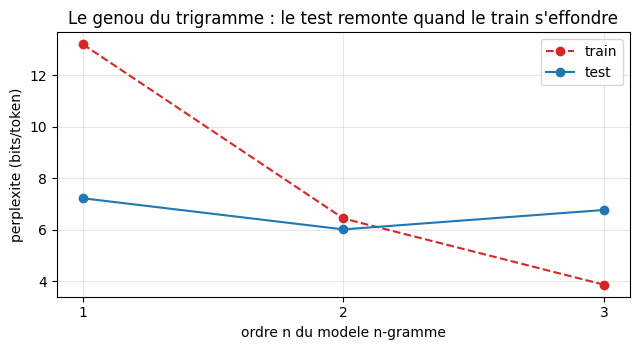

In [10]:
tri_count = Counter()
ctx2_count = Counter()
succ2_types = Counter()
for p in train_seq:
    tri_count.update(zip(p, p[1:], p[2:]))
    ctx2_count.update(zip(p, p[1:]))
for (a, b, w) in tri_count:
    succ2_types[(a, b)] += 1

def p_kn_tri(w, a, b):
    c_ab = ctx2_count.get((a, b), 0)
    if c_ab == 0:
        return p_kn(w, b)
    first = max(tri_count.get((a, b, w), 0) - D, 0.0) / c_ab
    lam = D * succ2_types.get((a, b), 0) / c_ab
    return first + lam * p_kn(w, b)

pp_tri_train = log2_pp([p_kn_tri(w, a, b) for p in train_seq for a, b, w in zip(p, p[1:], p[2:])])
pp_tri_test_val = log2_pp([p_kn_tri(w, a, b) for p in test_seq for a, b, w in zip(p, p[1:], p[2:])])

print(f"                {'n=1 (uni)':>12s} {'n=2 (KN)':>12s} {'n=3 (KN)':>12s}")
print(f"PP train      {pp_uni_train:12.2f} {pp_kn_train:12.2f} {pp_tri_train:12.2f}")
print(f"PP test       {pp_uni_test:12.2f} {pp_kn_test:12.2f} {pp_tri_test_val:12.2f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ns = [1, 2, 3]
ax.plot(ns, [pp_uni_train, pp_kn_train, pp_tri_train], "o--", color="#d62728", label="train")
ax.plot(ns, [pp_uni_test, pp_kn_test, pp_tri_test_val], "o-", color="#1f77b4", label="test")
ax.set_xticks(ns)
ax.set_xlabel("ordre n du modele n-gramme")
ax.set_ylabel("perplexite (bits/token)")
ax.set_title("Le genou du trigramme : le test remonte quand le train s'effondre")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture du résultat

**Le genou est mesuré, même lissé.** Sur le **test**, le bigramme KN gagne nettement (7.23 → 6.02 bits) — puis le trigramme **remonte** (6.02 → 6.77) : à 362 tokens d'entraînement, l'ordre 3 sur-apprend, et l'interpolation ne fait qu'adoucir le phénomène (une remontée de 0.75 bit, là où le MLE pur partait à l'infini dès le bigramme). La richesse du modèle doit être **proportionnelle aux données**, pas à l'ambition.

La paire train/test le montre en creux : le train du trigramme **s'effondre** (6.44 → 3.87) pendant que son test remonte — l'écart se retourne et se creuse, signature du sur-ajustement. (Au n=1, l'écart est inversé pour la raison vue en section 3 : le test, riche en `<UNK>` fréquents, y est plus facile que le train — un rappel que la perplexité se compare à jeu de phrases fixé, jamais entre deux jeux.)

Un LLM à 70 milliards de paramètres est l'autre bout du même axe : assez de données pour que « n » devienne « tout le contexte » — mais la perplexité y reste exactement la même métrique, celle que ce notebook a construite from scratch.

## 10. Ce que le dépôt y gagne — tableau final et ponts

Le tableau final rassemble les perplexités **test** de tous les modèles de ce notebook. C'est la carte que le deck 09 pourra enfin citer comme owner : n-grammes, lissage, perplexité — le gap mesuré par #16235 est fermé.

In [11]:
lignes = [
    ("Uniforme (temoin)", pp_unif, "PP == V exactement : l'instrument est prouve"),
    ("Unigramme MLE", pp_uni_test, "Zipf suffit a casser l'equiprobabilite"),
    ("Bigramme MLE", float("inf"), f"{zeros_test}/{total_pairs_test} paires inconnues -> log2(0)"),
    ("Laplace a=1", pp_test(lambda w, a: p_laplace(w, a)), "l'infini gueri, la distribution blessee"),
    ("Kneser-Ney interpolé", pp_kn_test, "la continuation bat la frequence"),
    ("KN trigramme", pp_tri_test_val, "le genou : le test remonte quand le train s'effondre"),
]
print(f"{'Modele':24s} {'PP test':>10s}   lecture")
print("-" * 100)
for nom, pp, note in lignes:
    val = "infinie" if pp == float("inf") else f"{pp:.2f}"
    print(f"{nom:24s} {val:>10}   {note}")

Modele                      PP test   lecture
----------------------------------------------------------------------------------------------------
Uniforme (temoin)             47.00   PP == V exactement : l'instrument est prouve
Unigramme MLE                  7.23   Zipf suffit a casser l'equiprobabilite
Bigramme MLE                infinie   1/83 paires inconnues -> log2(0)
Laplace a=1                   11.09   l'infini gueri, la distribution blessee
Kneser-Ney interpolé           6.02   la continuation bat la frequence
KN trigramme                   6.77   le genou : le test remonte quand le train s'effondre


### Lecture du résultat — et limites honnêtes

**Ce qui est démontré** : estimation MLE, vocabulaire fermé + `<UNK>`, split train/test, perplexité base 2 avec témoin d'instrument, Laplace avec son paradoxe mesuré, Kneser-Ney interpolé avec sa continuation — **chaque valeur vérifiée contre nltk**.

**Les limites, écrites** :

1. **Corpus minuscule** (440 tokens, dont ~350 au train) : les phénomènes sont amplifiés à dessein ; les ordres de grandeur ne se transfèrent pas à l'échelle.
2. **KN bigramme/trigramme interpolé, pas le backoff complet** de Chen & Goodman (plusieurs discounts par ordre) — la vérification nltk porte sur l'interpolé, identique des deux côtés.
3. **Convention de perplexité** : bits par token, bornes comprises, padding d'un seul `<s>` — documentée pour que toute comparaison future cite la même convention.
4. **Mots du test hors vocabulaire** : mappés `<UNK>`, jamais rejetés — c'est le comportement d'un système réel.

**Ponts dans le dépôt** : la tokenisation (mots vs BPE) vit dans `RAG-et-Memoire-Semantique/04-Tokenisation-From-Scratch` ; la perplexité **consommée** comme métrique vit dans `11_Quantization` (impact de la quantization) et `22_Evaluating_Generated_Text` (évaluation de sorties générées) ; les mécanismes d'attention qui ont remplacé les n-grammes vivent dans `TransformerVariants/TV-00b-Attention-Variants-from-scratch` ; le pipeline linguistique amont (POS, dépendances, NER) vit dans `23_TAL_Du_Mot_Aux_Dependances`. Ce notebook est le chaînon de comptage entre eux.

## Exercices

Les trois exercices suivent la règle du dépôt : le notebook s'exécute de bout en bout même non complété (`pass` / `return None`, jamais d'erreur volontaire).

### Exercice 1 — Perplexité d'une phrase donnée, par chaque modèle

Écrire `perplexite_phrase(phrase, modele)` qui prend une phrase en clair (« le renard tint un langage »), la mappe sur le vocabulaire (bornes comprises), et retourne la perplexité **selon un modèle au choix** (unigramme, Laplace, KN). Comparer les trois sur la même phrase : laquelle hésite le plus, et pourquoi l'ordre KN > Laplace > unigramme s'inverse-t-il parfois sur une phrase très vue au train ?

**Indice :** réutiliser `log2_pp` avec la probabilité adaptée ; le mapping passe par `mapper`.
**Étape 1 :** borner la phrase mappee. Etape 2 : construire la liste de probabilites. Etape 3 : retourner log2_pp.

In [12]:
def perplexite_phrase(phrase, modele):
    """Perplexite (bits/token) d'une phrase en clair selon le modele choisi.

    modele : 'uni' | 'laplace' | 'kn'
    """
    # TODO etudiant : borner la phrase mappee, puis evaluer chaque token.
    return None

### Exercice 2 — Trigramme de continuation : étendre N₁₊ à l'ordre 3

Le repli du trigramme utilise aujourd'hui le KN bigramme. Étendre la **continuation à l'ordre supérieur** : N₂₊(w) = nombre de bigrammes **distincts** (a, b) tels que (a, b, w) soit vu au train — puis remplacer P_cont dans le repli de `p_kn_tri` par cette distribution et mesurer la perplexité test. Gagne-t-on sur ce corpus ? Mesurer avant de conclure : la section 9 prédit un gain nul ou négatif (les contextes manquent), mais c'est la mesure qui décide.

**Indice :** un Counter sur les 2 premiers elements de tri_count suffit a construire N2+.
**Étape 1 :** N2_plus sur tri_count. Etape 2 : p_cont2 normalise. Etape 3 : variante de p_kn_tri et comparaison.

In [13]:
def p_cont2(w):
    """Distribution de continuation d'ordre 2 : N2+(w) / somme des N2+."""
    # TODO etudiant : compter les bigrammes distincts qui precedent w dans tri_count.
    return None

### Exercice 3 — Lissage de Jelinek-Mercer : l'interpolation simple

Entre Laplace (trop brutal) et Kneser-Ney (discount + continuation), il existe l'interpolation linéaire de Jelinek-Mercer : P_JM(w | a) = λ·P_MLE(w | a) + (1 − λ)·P_uni(w), avec λ ∈ [0, 1]. Implémenter `p_jm` et balayer λ ∈ {0.1, …, 0.9} : où est le minimum de perplexité test ? Comparer ce minimum à Kneser-Ney — laquelle des deux familles gagne, et quel ingrédient de KN explique l'écart ?

**Indice :** attention au cas P_MLE(w|a) == 0 : la formule reste valide, c'est tout l'interet.
**Étape 1 :** p_jm(w, a, lam). Etape 2 : balayage. Etape 3 : lecture face a KN.

In [14]:
def p_jm(w, a, lam=0.7):
    """Jelinek-Mercer : interpolation lineaire MLE/unigramme."""
    # TODO etudiant : combiner p_bi_mle et p_uni selon lam.
    return None

## Conclusion : le comptage comme fondation, la perplexité comme étalon

**Ce que ce notebook a construit** — et qu'aucun notebook du dépôt ne portait :

1. **L'estimation n-gramme complète** : vocabulaire fermé, `<UNK>`, MLE unigramme/bigramme/trigramme, sur le corpus fil rouge de la série ;
2. **La perplexité définie, mesurée et prouvée** : témoin uniforme PP = V exact, convention bits/token documentée ;
3. **Les deux lissages canoniques** : Laplace (avec son paradoxe mesuré en α-sweep) et Kneser-Ney interpolé (continuation counts, discount, redistribution exacte) — **tous deux vérifiés bit-exacte contre `nltk.lm`** ;
4. **Le genou du sur-ajustement** : la courbe perplexité-vs-n où le test remonte dès que le train s'effondre — mesuré, pas raconté.

**Références** : Kneser & Ney 1995, « Improved backing-off for m-gram language modeling » ; Chen & Goodman 1999, « An empirical study of smoothing techniques » ; Jurafsky & Martin, *Speech and Language Processing*, ch. 3 (n-gram language models) ; le deck `slides/09-traitement-automatique-langues` (section I).

**Verdict SOTA : SOTA-OK** — implémentations from scratch vérifiées contre la référence `nltk.lm`, aucune sortie de substitution.